In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("smartcart_customers (6).csv")

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy="median")
df["Income"]=si.fit_transform(df[["Income"]])
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [7]:
df["Age"]=2026-df["Year_Birth"]
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
max_date=df["Dt_Customer"].max()
df["Tenure"]=(max_date-df["Dt_Customer"]).dt.days

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [9]:
df["total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [10]:
df["total_children"]=df["Kidhome"]+df["Teenhome"]

In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate",
    "2n Cycle":"UnderGraduate",
    "Graduation":"graduate",
    "PhD":"postGraduate",
    "Master":"postGraduate"
})

In [13]:
df["Education"].value_counts()

Education
graduate         1127
postGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
df["living_with"]=df["Marital_Status"].replace({
    "Married":"Patner",
    "Together":"Patner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone",
})

In [16]:
df["living_with"].value_counts()

living_with
Patner    1444
Alone      796
Name: count, dtype: int64

In [17]:
df_cleaned=df.drop(columns=['ID', 'Year_Birth','Marital_Status','Kidhome','Teenhome', 'Dt_Customer','MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds'])

In [18]:
df_cleaned.shape

(2240, 15)

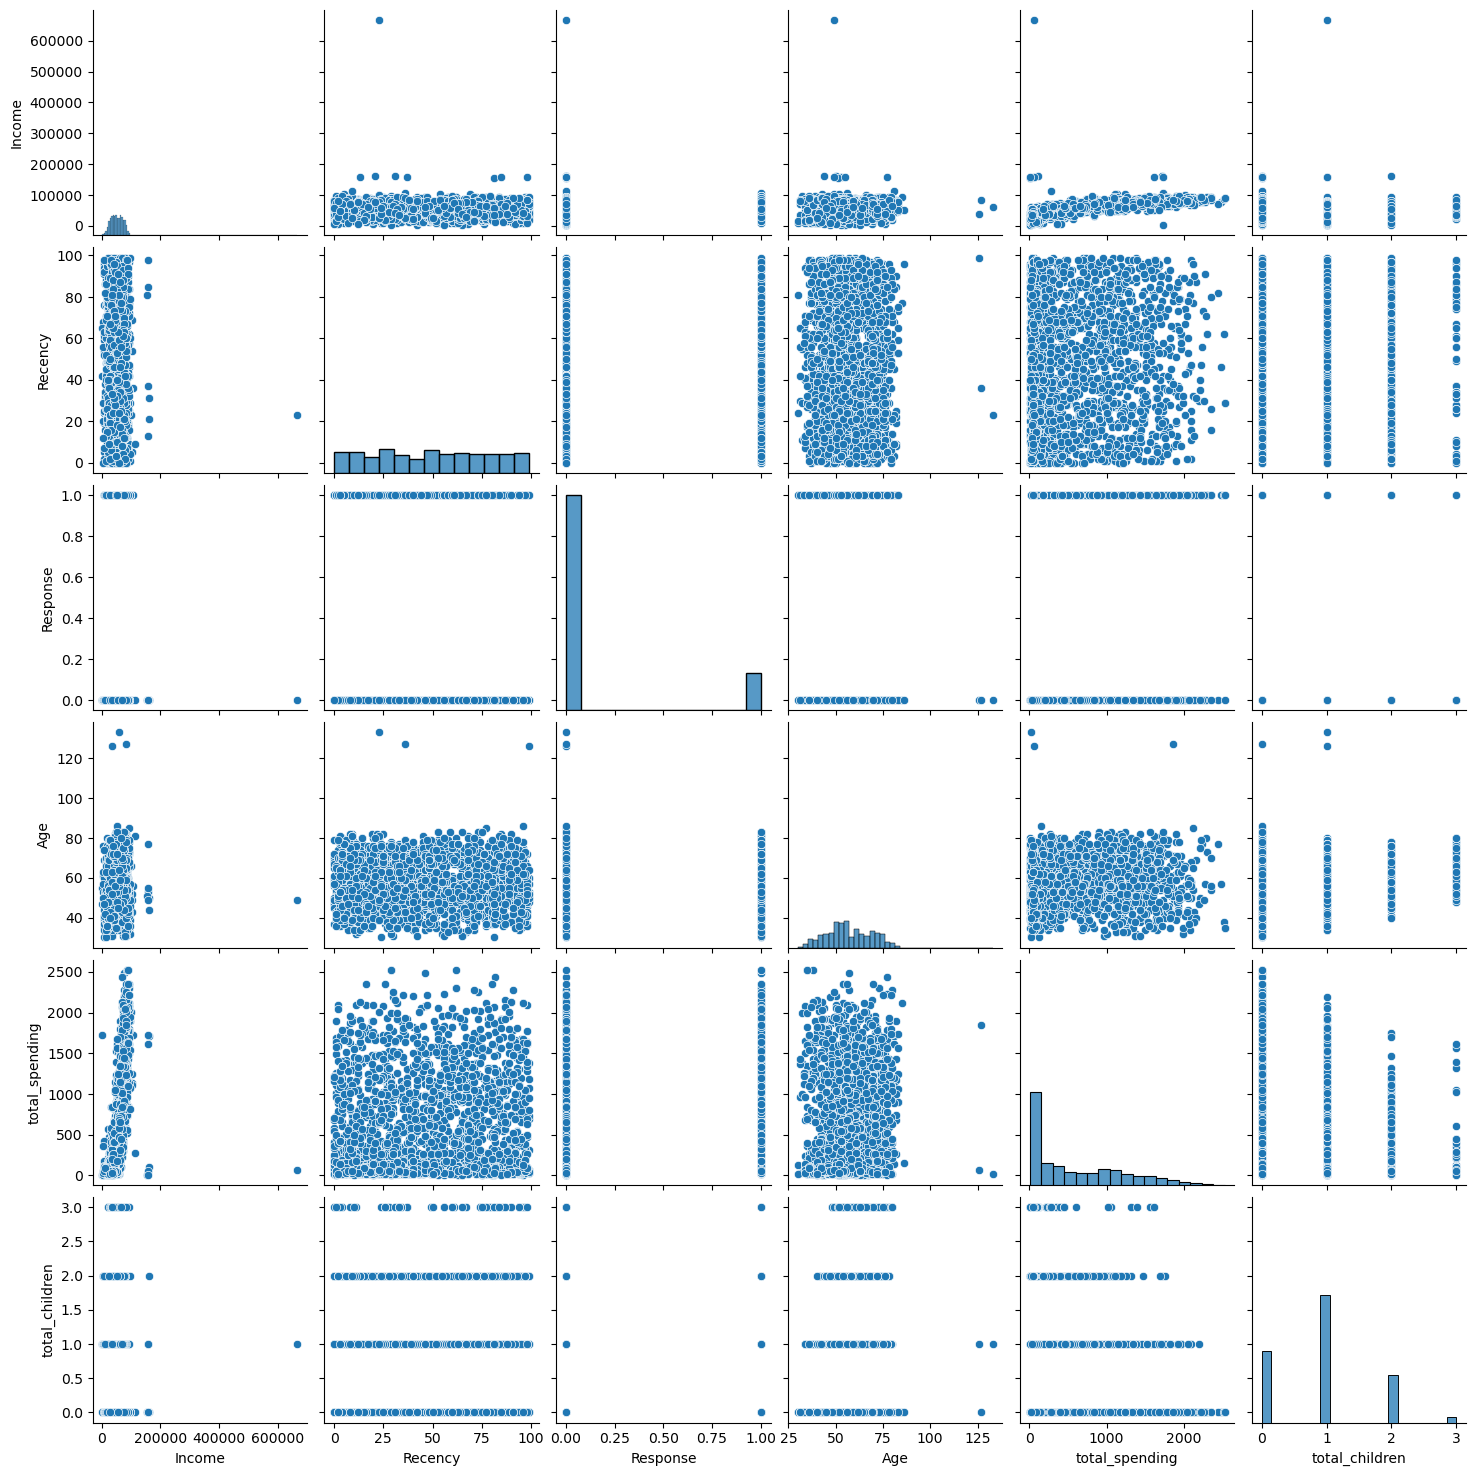

In [19]:
cols=["Income","Recency","Response","Age","total_spending","total_children"]
sns.pairplot(df_cleaned[cols])

In [20]:
#removing rows where outliers exist
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]

In [21]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

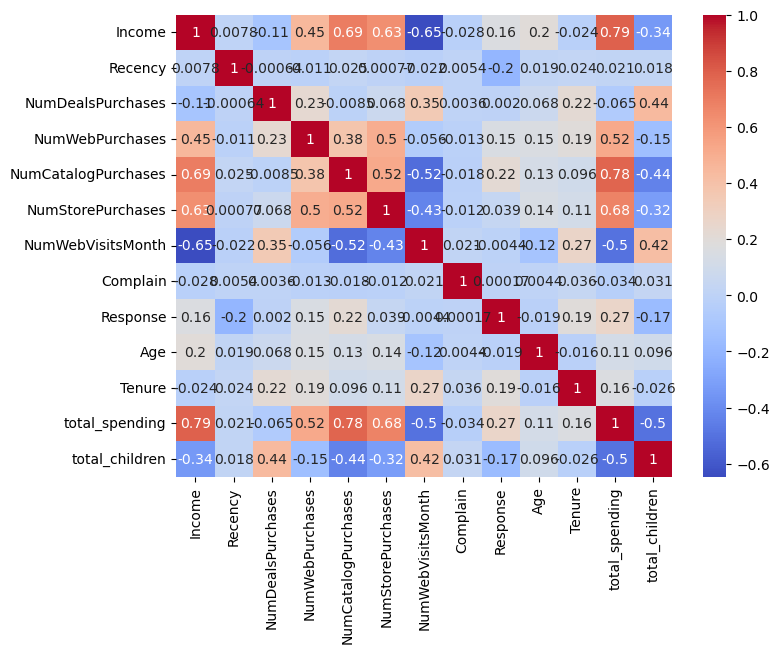

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [23]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,total_spending,total_children,living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Patner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Patner
4,postGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Patner


In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
ohe=OneHotEncoder()
cols=["Education","living_with"]
ohe_data=ohe.fit_transform(df_cleaned[cols])

In [25]:
ohe_df=pd.DataFrame(ohe_data.toarray(),columns=ohe.get_feature_names_out(cols),index=df_cleaned.index)

In [26]:
df_encoded=pd.concat([df_cleaned.drop(columns=cols),ohe_df],axis=1)

In [27]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,total_spending,total_children,Education_UnderGraduate,Education_graduate,Education_postGraduate,living_with_Alone,living_with_Patner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,1.0


In [28]:
#scaling
X=df_encoded
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

Text(0.5, 0, 'PCA1')

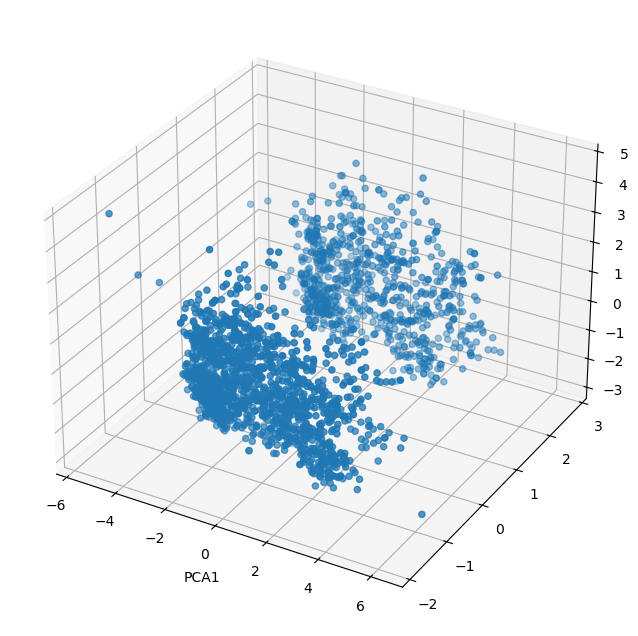

In [29]:
#Visualization
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
fig=plt.figure(figsize=(16,8))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_xlabel("PCA1")
ax.set_xlabel("PCA1")

In [30]:
##elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42)
    model.fit_predict(X_pca)
    wcss.append(model.inertia_)
k=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print(k.elbow)

4


In [31]:
##silhouette Score
from sklearn.metrics import silhouette_score
scores=[]
for i in range(2,11):
    model=KMeans(n_clusters=i,random_state=42)
    labels=model.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca,labels))

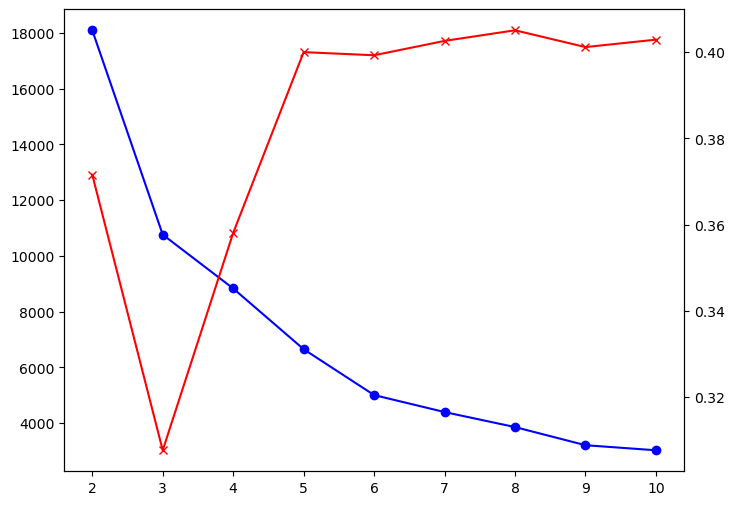

In [32]:
fig,ax1=plt.subplots(figsize=(8,6))
k_range=range(2,11)
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red")

0.358099615959623


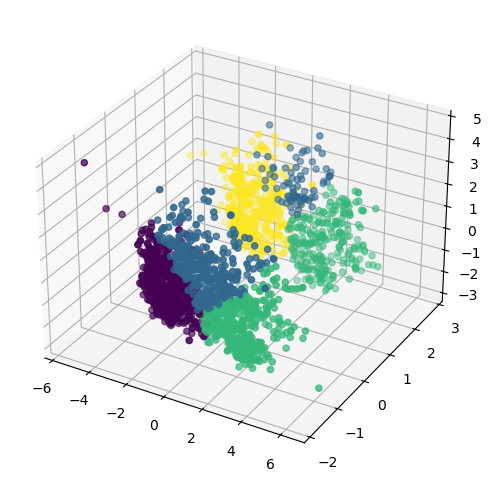

In [47]:
##KMeans
from sklearn.cluster import KMeans
model=KMeans(n_clusters=4,random_state=42)
labels=model.fit_predict(X_pca)
print(silhouette_score(X_pca,labels))
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

In [48]:
##Agglomerative
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(n_clusters=4)
labels=model.fit_predict(X_pca)
print(silhouette_score(X_pca,labels))

0.3792545615705887


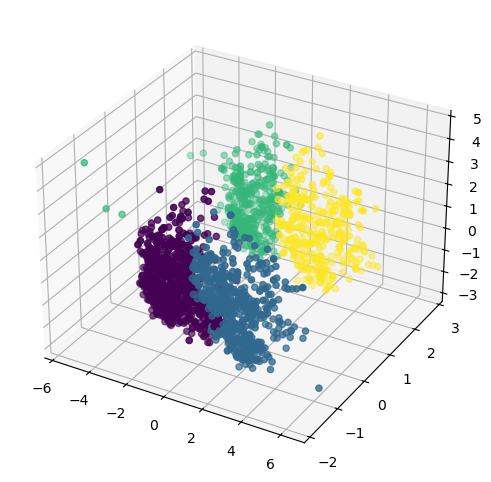

In [49]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

In [55]:
df_cleaned["cluster"]=labels
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,total_spending,total_children,living_with,cluster
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Patner,1
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Patner,0
4,postGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Patner,0


<Axes: xlabel='total_spending', ylabel='Income'>

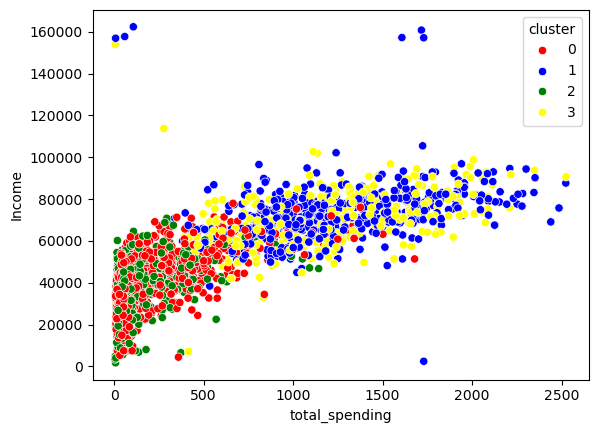

In [66]:
import seaborn as sns
sns.scatterplot(x=df_cleaned["total_spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=["red","blue","green","yellow"])

In [71]:
X["cluster"]=labels
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age      Tenure  total_spending  total_children  \
cluster   